<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/nprivaul/fractionalpdes/blob/master/fujita-type.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

This code solves the time-fractional Fujita-type equation 
$$\partial_t^\alpha u=-(-\Delta u)^{\gamma/2}+\lambda (p_0+p_1 u+\cdots +p_N u^N)$$ 
on the whole space $\mathbb{R}^d$ with initial condition $f$, $\lambda>0$, $p_k\in [0,1]$, $p_0+\cdots +p_N=1$ and $(\alpha , \gamma) = (0.5,0.5)$ or $(\alpha , \gamma ) = ( 0.5,2/3)$.

In [1]:
import math
import matplotlib.pyplot as plt
from scipy.stats import expon,uniform,norm
import numpy as np
from scipy.special import gammaln
import time
from multiprocessing import Pool

plt.rcParams.update({
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "legend.title_fontsize": 14,
    "xtick.major.pad": 8,        # Increase distance between x-axis and tick labels (default ~4)
    "figure.titlesize": 24,
    "axes.xmargin": 0,      # Equivalent to ax.margins(x=0)
    "figure.autolayout": True,  # Equivalent to plt.tight_layout()
})

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Thu Feb 26 19:50:07 2026

@author: gerar
"""

#=============================================================================
#MC ALGORITHM
#=============================================================================
def f(x,d,gamma): 
    """
    Initial condition - a function from R^d to [0,1]
    x=[x[1],...,x[d]] is an array if d>1; if d=1, x must be a float
    This initial condition leads to a stationary solution, useful for comparing the MC algorithm
    """
    A=1
    c=[0 for i in range(d)]
    normx=np.linalg.norm(np.array(x)-np.array(c))
    log_ratio=gammaln((d-gamma)/2)-gammaln((d+gamma)/2)
    ratio=np.exp(log_ratio/gamma)
    return A*(1.0+(0.5*A**(2/(d-gamma))*normx*ratio)**2)**((gamma-d)/2) 

def subordinator_rv(alpha):
    """
    This simulates S(1), where (S(t))_t is an \alpha-stable subordinator (Chambers, Mallows, Stuck (1976))
    alpha is a number in (0,1]
    """
    if alpha==1:
        return 1
    else:
        theta=math.pi*uniform.rvs()
        w=expon.rvs()
        aux1=math.sin((1-alpha)*theta)*(math.sin(alpha*theta))**(alpha/(1-alpha))
        aux2=(math.sin(theta))**(1/(1-alpha))
        aux3=aux1/aux2
        return (aux3/w)**((1-alpha)/alpha)

    
def stable_rv(gamma,d,t):
    """
    This simulates X(t), where (X(t))_t is a d-dimensional symmetric gamma-stable process
    gamma is a number in (0,2], d is a natural number, t geq 0
    If d==1, the output is a float; if d>1, it is an array 
    """
    if d==1:
        return norm.rvs()*(2*subordinator_rv(gamma/2))**(1/2)*t**(1/gamma)  #Scaling property
    else:
       aux1=norm.rvs(size=d)
       aux2=subordinator_rv(gamma/2)
    return [aux1[i]*(2*aux2)**(1/2)*t**(1/gamma) for i in range(d)]
   
def discrete_rv(p):
    """
    This simulates a random variable on {0,1,..., N}, N>1, according to law [p_0,p_1,...,p_N]
    p_k is a number in [0,1] and p_0+p_1+...+p_N=1
    """
    aux=0
    u=uniform.rvs()
    for i in range(len(p)):
        if u<aux+p[i]:
            return i
        else:
            aux=aux+p[i]

            
def branching(alpha,gamma,lam,p,d,x,T):
    """
    This simulates the random variable U=e^{lambda W_t^alpha} prod_{k in mathcal{N}_t^alpha}f(x+Y_k^alpha(t))
    alpha,gam,lam,p,d are as in "PARAMETERS"
    x=[x[1],...,x[d]] is an array representing a point, T is a positive number representing time
    """
    s1=subordinator_rv(alpha)
    tau=expon.rvs()/lam                             #Exponential lifetime 
    sigma=s1*tau**(1/alpha)                         #Mittag Leffler lifetime
    if sigma>T:                                     #No branching case
        et=(T/s1)**alpha                            #Inverse stable subordinator law
        dx=stable_rv(gamma,d,et)                    #Spatial displacement
        if d==1:                                    #Dimension one case
            Y=x+dx                                  #Position at branching time
            return f(Y,d,gamma)*math.exp(lam*et)
        else:                                       #Dimension greater than one
            Y=[x[i]+dx[i] for i in range(d)]
            return f(Y,d,gamma)*math.exp(lam*et)
    else:                                           #Branching case
        branches=discrete_rv(p)                     #Number of branches
        aux=math.exp(lam*tau)
        dx=stable_rv(gamma,d,tau)                   
        if d==1:
            Y=x+dx
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma)    #Recursion
            return aux 
        else:
            Y=[x[i]+dx[i] for i in range(d)]
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma) 
            return aux
            
def mc_fujita_sol(alpha,gamma,lam,p,d,x,T,n_iter):   
    """
    This is the Monte Carlo estimator of the solution at (x,T)
    alpha,gam,lam,p,d are as in the section "Parameters"
    n_iter is the sample size
    """                      
    aux=0
    for i in range(n_iter):
        aux=aux+branching(alpha,gamma,lam,p,d,x,T)
    return aux/n_iter               #MC estimator

Running 2D case...
Computing 2D MC solution using 8 cores...
Progress: 10/1681 (0.6%)
Progress: 20/1681 (1.2%)
Progress: 30/1681 (1.8%)
Progress: 40/1681 (2.4%)
Progress: 50/1681 (3.0%)
Progress: 60/1681 (3.6%)
Progress: 70/1681 (4.2%)
Progress: 80/1681 (4.8%)
Progress: 90/1681 (5.4%)
Progress: 100/1681 (5.9%)
Progress: 110/1681 (6.5%)
Progress: 120/1681 (7.1%)
Progress: 130/1681 (7.7%)
Progress: 140/1681 (8.3%)
Progress: 150/1681 (8.9%)
Progress: 160/1681 (9.5%)
Progress: 170/1681 (10.1%)
Progress: 180/1681 (10.7%)
Progress: 190/1681 (11.3%)
Progress: 200/1681 (11.9%)
Progress: 210/1681 (12.5%)
Progress: 220/1681 (13.1%)
Progress: 230/1681 (13.7%)
Progress: 240/1681 (14.3%)
Progress: 250/1681 (14.9%)
Progress: 260/1681 (15.5%)
Progress: 270/1681 (16.1%)
Progress: 280/1681 (16.7%)
Progress: 290/1681 (17.3%)
Progress: 300/1681 (17.8%)
Progress: 310/1681 (18.4%)
Progress: 320/1681 (19.0%)
Progress: 330/1681 (19.6%)
Progress: 340/1681 (20.2%)
Progress: 350/1681 (20.8%)
Progress: 360/1681 

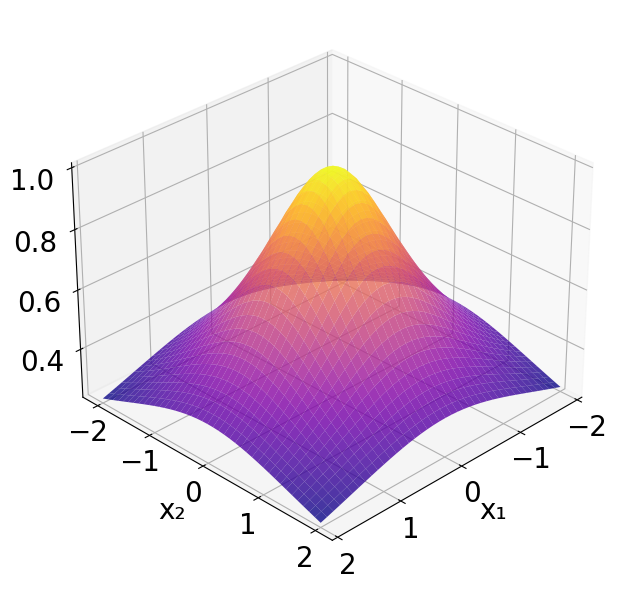

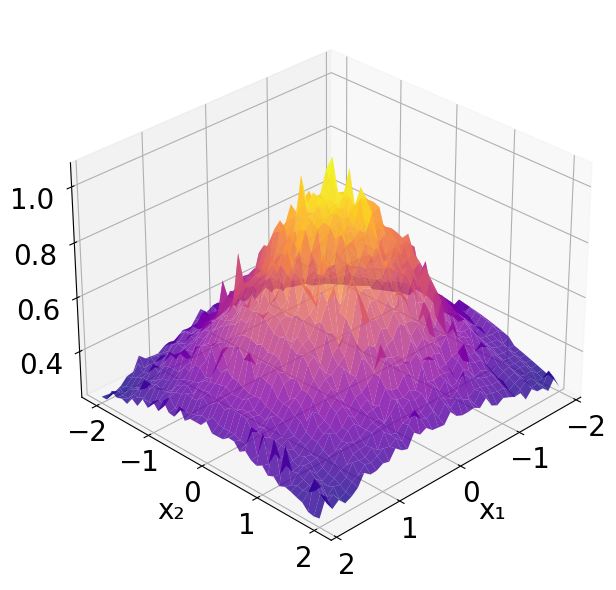

Time = 312.09 seconds


In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from multiprocessing import Pool, cpu_count
from functools import partial

#==============================================================================
#Example - two dimensional case with multiprocessing
#==============================================================================
print("Running 2D case...")
start = time.time()        

#PARAMETERS
alpha = 0.5
lam = 1
d = 2
gamma = 2/3
p = [0, 0, 1] 
n_iter = 1000
T = 0.5

#Space discretization
a = -2        #Interval [a,b] x [c,dd] for [x1,x2]
b = 2
c = -2
dd = 2
nx1 = 41      #Number of points in [a,b] (reduced for speed)
nx2 = 41      #Number of ponts in [c,d] (reduced for speed)
x1 = [a + i*(b-a)/(nx1-1) for i in range(nx1)]      #Space discretization x1
x2 = [c + i*(dd-c)/(nx2-1) for i in range(nx2)]     #Space discretization x2

#Create meshgrid for plotting
X1, X2 = np.meshgrid(x1, x2, indexing='ij')

#Compute initial condition for comparison
initial_2d = np.zeros((nx1, nx2))
for i in range(nx1):
    for j in range(nx2):
        initial_2d[i, j] = f([x1[i], x2[j]], d, gamma)

# Function to compute solution for a single grid point
def compute_point(args):
    """Compute MC solution for a single grid point"""
    i, j, x1_val, x2_val, alpha, gamma, lam, p, d, T, n_iter = args
    result = mc_fujita_sol(alpha, gamma, lam, p, d, [x1_val, x2_val], T, n_iter)
    return i, j, result

# Prepare arguments for all grid points
args_list = []
for i in range(nx1):
    for j in range(nx2):
        args_list.append((
            i, j, x1[i], x2[j], alpha, gamma, lam, p, d, T, n_iter
        ))

# Compute MC solution using multiprocessing
print(f"Computing 2D MC solution using {cpu_count()} cores...")
y_2d = np.zeros((nx1, nx2))

# Use multiprocessing Pool
with Pool(processes=cpu_count()) as pool:
    # Use imap_unordered for better performance with progress tracking
    results = pool.imap_unordered(compute_point, args_list)
    
    # Track progress
    total_points = nx1 * nx2
    completed = 0
    
    for i, j, result in results:
        y_2d[i, j] = result
        completed += 1
        if completed % 10 == 0 or completed == total_points:
            print(f"Progress: {completed}/{total_points} ({(completed/total_points)*100:.1f}%)")

# Error
error = np.max([[initial_2d[i, j]-y_2d[i, j] for j in range(nx2)] for i in range(nx1)])

# if not os.path.isdir('logs/'):
#    os.makedirs('logs/')

# Plotting
fig1 = plt.figure(figsize=(7,6))
ax1 = fig1.add_subplot(111, projection='3d')

surf1 = ax1.plot_surface(X1, X2, initial_2d, cmap='plasma', alpha=0.8, linewidth=0)

# ax1.set_title('Initial Condition')
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.tick_params(axis='x', pad=0)
ax1.tick_params(axis='y', pad=0)

#ax1.set_zlabel('u(0,x)')
ax1.view_init(elev=30, azim=45)

plt.tight_layout()
plt.savefig("initial_condition.pdf", bbox_inches="tight")
plt.show()

fig2 = plt.figure(figsize=(7,6))
ax2 = fig2.add_subplot(111, projection='3d')

surf2 = ax2.plot_surface(X1, X2, y_2d, cmap='plasma', alpha=0.8, linewidth=0)

# ax2.set_title(
#     f'MC Solution at t = {T}\n'
#     rf"$\alpha={alpha}, \gamma={round(gamma,3)}, \lambda={lam}, "
#     rf"N={n_iter}, p={p}, Error={round(error,4)}$"
# )

ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')

ax2.tick_params(axis='x', pad=0)
ax2.tick_params(axis='y', pad=0)
# ax2.set_zlabel(f'u({T},x)')
ax2.view_init(elev=30, azim=45)

plt.tight_layout()
plt.savefig("final_solution.pdf", bbox_inches="tight")
plt.show()

print(f"Time = {time.time() - start:.2f} seconds")

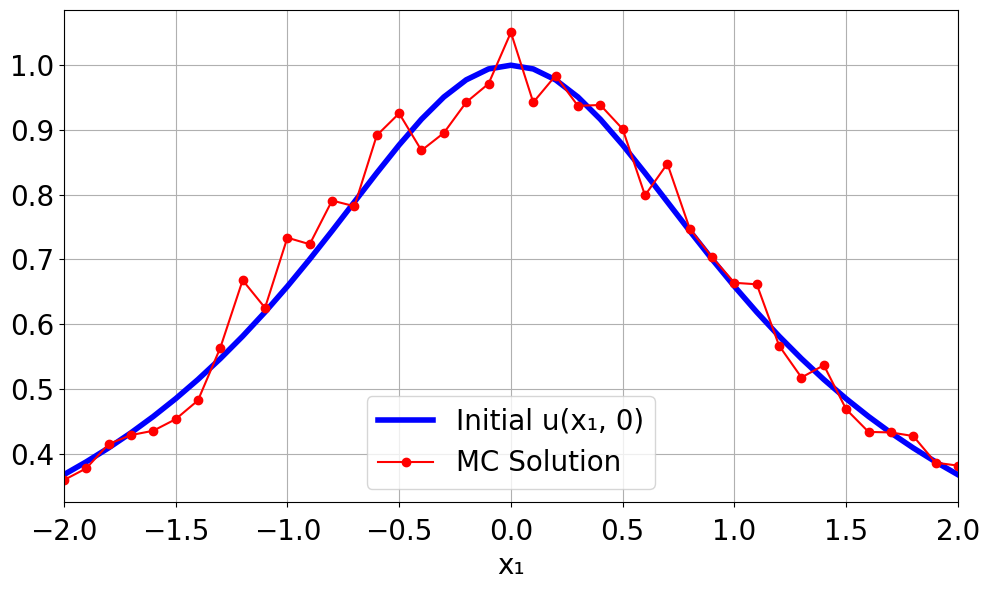

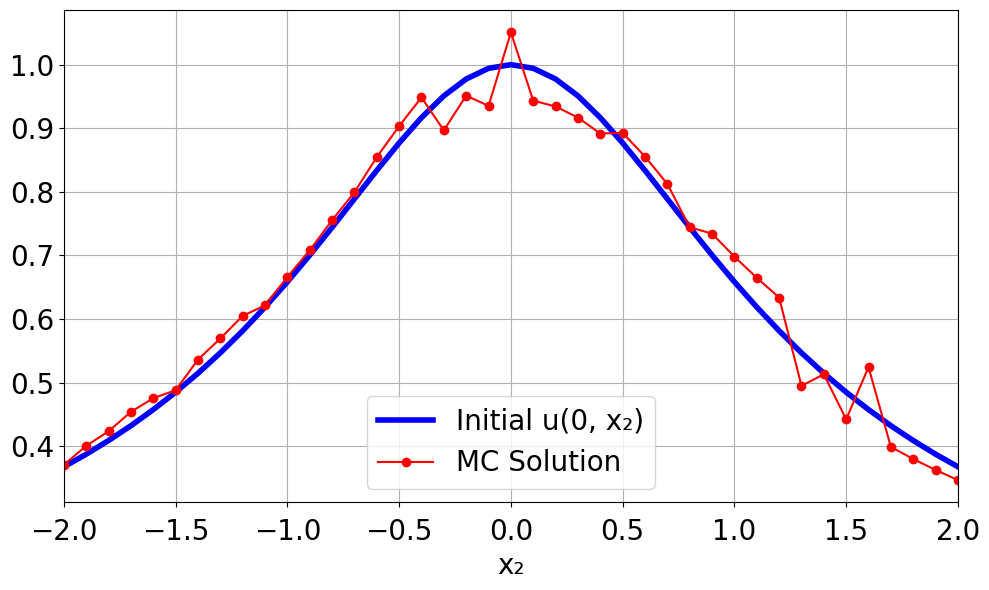

In [4]:
# MULTIPROCESSING

# Panel 3: Cross-sections through the center
# fig, ax3 = plt.subplots(1, 1, figsize=(10, 6))
center_idx = nx1 // 2

# Cross-section along x1 axis at x2 = 0
x2_zero_idx = np.argmin(np.abs(x2))  # Find index closest to x2=0
cross_section_x1 = y_2d[:, x2_zero_idx]

# Cross-section along x2 axis at x1 = 0  
x1_zero_idx = np.argmin(np.abs(x1))  # Find index closest to x1=0
cross_section_x2 = y_2d[x1_zero_idx, :]

#ax3.plot(x1, cross_section_x1, 'b-', label=f'u(x₁, x₂={x2[x2_zero_idx]:.1f})', linewidth=2)
#ax3.plot(x2, cross_section_x2, 'r-', label=f'u(x₁={x1[x1_zero_idx]:.1f}, x₂)', linewidth=2)

# Add initial condition cross-sections for comparison
initial_cross_x1 = initial_2d[:, x2_zero_idx]
initial_cross_x2 = initial_2d[x1_zero_idx, :]
#ax3.plot(x1, initial_cross_x1, 'b--', label='Initial u(x₁, 0)', alpha=0.7)
#ax3.plot(x2, initial_cross_x2, 'r--', label='Initial u(0, x₂)', alpha=0.7)

#ax3.set_xlabel('x')
# ax3.set_ylabel('u(t,x)')
# ax3.set_title('Cross-sections through center')
#ax3.legend()
#ax3.grid(True, alpha=0.3)

#plt.tight_layout()
#plt.savefig('2dplot2.png', format='png', dpi=150)
#plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x1, initial_cross_x1,label='Initial u(x₁, 0)',color='blue',linestyle='-',lw=4)
ax.plot(x1, cross_section_x1, label='MC Solution', linestyle='-',marker='.',color='red',markersize=12,lw=1.5)
ax.set_xlabel("x₁")
ax.margins(x=0)
ax.legend(loc="lower center", fontsize=20)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig("2dplot2x.pdf", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x1, initial_cross_x2,label='Initial u(0, x₂)',color='blue',linestyle='-',lw=4)
ax.plot(x2, cross_section_x2, label='MC Solution', linestyle='-',marker='.',color='red',markersize=12,lw=1.5)
ax.set_xlabel("x₂")
ax.margins(x=0)
ax.legend(loc="lower center", fontsize=20)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig("2dplot2y.pdf", bbox_inches="tight")

In [5]:
# # # Additional 2D visualizations (heatmap and contour)
# # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# # # Heatmap
# # im1 = ax1.imshow(y_2d.T, extent=[a, b, c, dd], origin='lower', cmap='viridis', aspect='equal')
# # ax1.set_title(f'Heatmap - MC Solution at t = {T}')
# # ax1.set_xlabel('x₁')
# # ax1.set_ylabel('x₂')
# # plt.colorbar(im1, ax=ax1)

# # # Contour plot
# # contour = ax2.contourf(X1, X2, y_2d, levels=20, cmap='viridis')
# # ax2.set_title(f'Contour Plot - MC Solution at t = {T}')
# # ax2.set_xlabel('x₁')
# # ax2.set_ylabel('x₂')
# # plt.colorbar(contour, ax=ax2)

# # plt.tight_layout()
# # plt.savefig('2dplot3.png', format='png', dpi=150)
# # plt.show()

# # print("2D visualization completed!")

# fig1, ax1 = plt.subplots(figsize=(7,6))

# im1 = ax1.imshow(
#     y_2d.T,
#     extent=[a, b, c, dd],
#     origin='lower',
#     cmap='viridis',
#     aspect='equal'
# )

# # ax1.set_title(f'Heatmap - MC Solution at t = {T}')
# ax1.set_xlabel('x₁')
# ax1.set_ylabel('x₂')

# plt.colorbar(im1, ax=ax1)

# plt.tight_layout()
# plt.savefig('heatmap.png', format='png', dpi=150)
# plt.show()

# fig2, ax2 = plt.subplots(figsize=(7,6))

# contour = ax2.contourf(
#     X1, X2, y_2d,
#     levels=20,
#     cmap='viridis'
# )

# # ax2.set_title(f'Contour Plot - MC Solution at t = {T}')
# ax2.set_xlabel('x₁')
# ax2.set_ylabel('x₂')

# plt.colorbar(contour, ax=ax2)

# plt.tight_layout()
# plt.savefig('contour.png', format='png', dpi=150)
# plt.show()

# ############################################################################### 
# #Example 3 - higher dimensions (optional, commented for speed)
# """
# print("Running 10D case...")
# d=10

# #Space discretization - we consider points [x[1],0,0,...,0]
# a=-2        #Interval [a,b] for x[1]
# b=2
# nx1=10      #Number of points in [a,b]
# x_10d=[[a+i*(b-a)/(nx1-1)] + [0]*9 for i in range(nx1)]    #Space discretization 

# #MC solution
# y_10d = [mc_kpp_sol(alpha,gamma,lam,p,d,x_10d[i],T,n_iter) for i in range(len(x_10d))]

# #Plots
# plt.figure(figsize=(10, 6))
# plt.plot([x_10d[i][0] for i in range(nx1)], y_10d, 'bo-', label="MC estimator", linewidth=2)
# plt.title(f"10D Time-Fractional F-KPP Equation\n"rf"$\alpha={alpha}, gamma={gamma}, lambda={lam}, t={T}$")
# plt.xlabel(r"$x_1$")
# # plt.ylabel(r"$u(t,x_1,0,...,0)$")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()
# """
